# **Deep Learning -Anomaly Detection with U-Net Autoencoder- Spring 2025**

CELL 1 — CONFIG, IMPORTS, DETERMINISTIC BLOCK, NAMED CONSTANTS, SHAREHOLDING CONFIG

In [10]:
# This cell sets up CONFIG and deterministic behavior.
# Deterministic setup
import os, random
# Fix Python hash seed
os.environ['PYTHONHASHSEED'] = str(42)
# Try to make cuBLAS deterministic if supported
os.environ.setdefault('CUBLAS_WORKSPACE_CONFIG', ':4096:8')


# CONFIG (this section change settings for quick vs final runs)
from pathlib import Path
import json, random, os, math

# DATASET CONFIG
DATASET_CATEGORY = 'hazelnut'   

QUICK_RUN = True

if QUICK_RUN:
    IMAGE_SIZE = 128
    BATCH_SIZE = 8
    EPOCHS = 3
    LR = 1e-3
else:
    IMAGE_SIZE = 256
    BATCH_SIZE = 12   # adjust down if hit OOM
    EPOCHS = 30
    LR = 1e-3

WORK_DIR = Path('/kaggle/working/mvtec_hazelnut_resnet_unet_mse_only')
WORK_DIR.mkdir(parents=True, exist_ok=True)

# REPRODUCIBILITY
GLOBAL_SEED = 42

# MODEL / TRAINING OPTIONS
WEIGHT_DECAY = 1e-5          # small weight decay
CLIP_GRAD_NORM = 2.0         # gradient clipping
EARLY_STOPPING_PATIENCE = 7  # patience for val loss

# Misc
NUM_WORKERS = 2



# flags for choose thresholding strategy at runtime.
# THRESHOLD_STRATEGY:
# 'val_percentile'   : threshold using validation normal images percentiles (e.g., 99th)
# 'image_youden'     : pick threshold from image-level ROC (Youden) (requires labels available for calibration)
# 'pixel_youden'     : pick pixel-level threshold from pixel ROC (requires calibration pixel labels)
# 'calib_optimize_f1': use calibration set to pick threshold that maximizes F1
THRESHOLD_STRATEGY = 'calib_optimize_f1'  # default strategy 
CALIBRATION_FRACTION = 0.5  # fraction of the original test set used for calibration (deterministic split)  [Calibration split]


# IMPORTS
import numpy as np
import torch, torchvision
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision import transforms
from torchvision.transforms.functional import InterpolationMode
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, precision_recall_fscore_support, roc_curve, auc
import time, tqdm


# using skimage.structural_similarity for SSIM computations
from skimage.metrics import structural_similarity as skimage_ssim

import math

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)

# SET GLOBAL SEED (reproducibility) 
def set_seed(seed=GLOBAL_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    try:
        torch.use_deterministic_algorithms(True)
    except Exception:
        pass

set_seed(GLOBAL_SEED)

# Save config for record
cfg = dict(DATASET_CATEGORY=DATASET_CATEGORY, QUICK_RUN=QUICK_RUN, IMAGE_SIZE=IMAGE_SIZE,
           BATCH_SIZE=BATCH_SIZE, EPOCHS=EPOCHS, LR=LR, GLOBAL_SEED=GLOBAL_SEED,
           WEIGHT_DECAY=WEIGHT_DECAY, WORK_DIR=str(WORK_DIR),
           THRESHOLD_STRATEGY=THRESHOLD_STRATEGY, CALIBRATION_FRACTION=CALIBRATION_FRACTION)

with open(WORK_DIR / 'config.json','w') as f:
    json.dump(cfg, f, indent=2)

print("Config saved to", WORK_DIR / 'config.json')


Device: cuda
Config saved to /kaggle/working/mvtec_hazelnut_resnet_unet_mse_only/config.json


CELL 2 — LOCATE DATA & DATASET CLASS, DETERMINISTIC SPLIT & CALIBRATION/TEST SPLIT

In [11]:
# This cell builds datasets and dataloaders.
# Deterministically split the original test set into calibration and final test subsets.
# Also pass the reproducible generator to all DataLoaders to ensure consistent ordering.


# Auto-detect dataset under /kaggle/input
KAGGLE_INPUT = Path('/kaggle/input')

def find_dataset_root(category='hazelnut'):
    for p in KAGGLE_INPUT.iterdir():
        if p.is_dir():
            for sub in p.rglob('*'):
                if sub.is_dir() and sub.name.lower() == category.lower():
                    return sub.parent
    return None

DATA_ROOT = find_dataset_root(DATASET_CATEGORY)
if DATA_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the MVTec dataset under /kaggle/input. Please add the dataset in the right-side 'Add data' panel."
    )

print("Using DATA_ROOT =", DATA_ROOT)
category_root = Path(DATA_ROOT) / DATASET_CATEGORY
print("Category root:", category_root)

def list_images(folder):
    folder = Path(folder)
    return sorted([p for p in folder.glob('*') if p.suffix.lower() in ('.png','.jpg','.jpeg')])

class MVTecHazelnutDataset(Dataset):
    def __init__(self, root:Path, mode='train', transform=None, img_list=None):
        """
        mode:
        'train'/'val' : uses root/train/good images (img_list optional to subset indices)
        'test' : collects images under root/test/* and pairs with ground_truth if available
        """
        self.root = Path(root)
        self.mode = mode
        self.transform = transform
        self.img_paths = []
        self.mask_paths = []
        if mode in ('train','val'):
            base_list = list_images(self.root / 'train' / 'good')
            if img_list is not None:
                # img_list is list of indices or paths; accept list of indices
                if all(isinstance(x, int) for x in img_list):
                    self.img_paths = [base_list[i] for i in img_list]
                else:
                    # assume list of Paths
                    self.img_paths = [Path(x) for x in img_list]
            else:
                self.img_paths = base_list
            self.mask_paths = [None] * len(self.img_paths)
        elif mode == 'test':
            test_dir = self.root / 'test'
            imgs = []
            for sub in sorted(test_dir.iterdir()):
                if sub.is_dir():
                    imgs += list_images(sub)
            self.img_paths = sorted(imgs)
            # locate ground truth masks
            gt_root = self.root / 'ground_truth'
            mask_map = {}
            if gt_root.exists():
                for gsub in gt_root.iterdir():
                    if gsub.is_dir():
                        for mp in list_images(gsub):
                            k = mp.stem.replace('_mask','')
                            mask_map[k] = mp
            self.mask_paths = [ mask_map.get(p.stem, None) for p in self.img_paths ]
        else:
            raise ValueError("mode must be 'train','val', or 'test'")

    def __len__(self):
        return len(self.img_paths)

    def __getitem__(self, idx):
        p = self.img_paths[idx]
        img = Image.open(p).convert('RGB')
        mask = None
        if self.mode == 'test' and self.mask_paths[idx] is not None:
            mask = Image.open(self.mask_paths[idx]).convert('L')
        if self.transform:
            img = self.transform(img)
            if mask is not None:
                # use InterpolationMode.NEAREST for masks
                mask = transforms.functional.resize(mask, (img.shape[1], img.shape[2]), interpolation=InterpolationMode.NEAREST)
                mask = transforms.ToTensor()(mask).float()
            else:
                mask = torch.zeros((1, img.shape[1], img.shape[2]), dtype=torch.float32)
        return img, mask, str(self.img_paths[idx].name)

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
])
test_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

# Build datasets and deterministic split (no leakage).
# two dataset objects with identical ordering but different transforms created
full_train_with_train_transform = MVTecHazelnutDataset(category_root, mode='train', transform=train_transform)
full_train_with_test_transform = MVTecHazelnutDataset(category_root, mode='train', transform=test_transform)

n = len(full_train_with_train_transform)
val_count = max(1, int(0.1 * n))
train_count = n - val_count

# deterministic permutation using global seed
rng = torch.Generator()
rng.manual_seed(GLOBAL_SEED)
perm = torch.randperm(n, generator=rng).tolist()
train_idx = perm[:train_count]
val_idx = perm[train_count:]

# Create Subsets referencing the two dataset objects 
train_dataset = Subset(full_train_with_train_transform, train_idx)
val_dataset = Subset(full_train_with_test_transform, val_idx)

# Original test dataset (all test images)
test_dataset_full = MVTecHazelnutDataset(category_root, mode='test', transform=test_transform)


# Deterministic split of test_dataset_full into calibration and final test sets.
# CALIBRATION_FRACTION of the test dataset will be use for calibration (threshold tuning),
# and the rest for final evaluation.

m = len(test_dataset_full)
if m == 0:
    raise RuntimeError("Test dataset is empty; ensure MVTec category 'test' exists.")

# Deterministic permutation for test split
rng2 = torch.Generator()
rng2.manual_seed(GLOBAL_SEED + 1)
perm_test = torch.randperm(m, generator=rng2).tolist()
calib_count = int(math.floor(CALIBRATION_FRACTION * m))
calib_idx = perm_test[:calib_count]
final_test_idx = perm_test[calib_count:]

calib_dataset = Subset(test_dataset_full, calib_idx)
final_test_dataset = Subset(test_dataset_full, final_test_idx)


# REPRODUCIBILITY

def seed_worker(worker_id):
    """
    Sets the seed for a DataLoader worker to ensure reproducible augmentations.
    """
    # Use the global seed and offset it by the worker ID
    worker_seed = GLOBAL_SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

# Create a generator for reproducible shuffling in the main process
g = torch.Generator()
g.manual_seed(GLOBAL_SEED)

from torch.utils.data import DataLoader
train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=True, 
    num_workers=NUM_WORKERS, 
    pin_memory=True,
    worker_init_fn=seed_worker,  
    generator=g                 
)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=g  
)
# Pass generator to calibration and final test loaders too (deterministic ordering)
calib_loader = DataLoader(
    calib_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=g
)
final_test_loader = DataLoader(
    final_test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    worker_init_fn=seed_worker,
    generator=g
)

print(f"Total train/good images: {n}, Train images: {len(train_dataset)}, Val images: {len(val_dataset)}, Test images total: {m}, Calibration: {len(calib_dataset)}, Final test: {len(final_test_dataset)}")


Using DATA_ROOT = /kaggle/input/mvtec-ad
Category root: /kaggle/input/mvtec-ad/hazelnut
Total train/good images: 391, Train images: 352, Val images: 39, Test images total: 110, Calibration: 55, Final test: 55


CELL 3 — MODEL (U-NET DECODER WITH RESNET-50 ENCODER)

In [12]:
import torchvision.models as models

class ConvRelu(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self,x): return self.conv(x)

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        self.conv = ConvRelu(in_ch, out_ch)
    def forward(self, x, skip):
        x = self.up(x)
        if x.shape != skip.shape:
            diffY = skip.size()[2] - x.size()[2]
            diffX = skip.size()[3] - x.size()[3]
            x = F.pad(x, [diffX//2, diffX - diffX//2, diffY//2, diffY - diffY//2])
        x = torch.cat([skip, x], dim=1)
        return self.conv(x)

class Model(nn.Module):
    def __init__(self, pretrained_encoder=True):
        super().__init__()
        # ImageNet normalization constants 
        self.register_buffer('imagenet_mean', torch.tensor([0.485, 0.456, 0.406]).view(1,3,1,1))
        self.register_buffer('imagenet_std', torch.tensor([0.229, 0.224, 0.225]).view(1,3,1,1))

        # Create a ResNet-50 encoder skeleton (weights loaded in init())
        resnet = models.resnet50(pretrained=False)
        self.enc_conv1 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)  # -> 64
        self.enc_pool = resnet.maxpool
        self.enc_layer1 = resnet.layer1  # -> 256
        self.enc_layer2 = resnet.layer2  # -> 512
        self.enc_layer3 = resnet.layer3  # -> 1024
        self.enc_layer4 = resnet.layer4  # -> 2048

        # Decoder
        self.up3 = Up(2048 + 1024, 1024)
        self.up2 = Up(1024 + 512, 512)
        self.up1 = Up(512 + 256, 256)
        self.up0 = Up(256 + 64, 128)

        # Add a final upsampling layer to match input size
        self.final_up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        

        self.final_conv = nn.Conv2d(128, 3, kernel_size=1)
        self.out_act = nn.Sigmoid()

        self._pretrained_requested = pretrained_encoder

    def init(self, pretrained=True):
        """
        Proper initialization:
        If pretrained=True, load torchvision ResNet-50 pretrained encoder weights
        """
        if pretrained:
            resnet_pre = models.resnet50(pretrained=True)
            # copy encoder blocks weights individually 
            # conv1 + bn1
            self.enc_conv1[0].load_state_dict(resnet_pre.conv1.state_dict())
            self.enc_conv1[1].load_state_dict(resnet_pre.bn1.state_dict())
            # layers
            self.enc_layer1.load_state_dict(resnet_pre.layer1.state_dict())
            self.enc_layer2.load_state_dict(resnet_pre.layer2.state_dict())
            self.enc_layer3.load_state_dict(resnet_pre.layer3.state_dict())
            self.enc_layer4.load_state_dict(resnet_pre.layer4.state_dict())
            print("Loaded ImageNet pretrained weights into encoder.")
        else:
            print("Initialized without pretrained encoder weights.")

        # Initialize decoder weights only 
        def init_decoder_weights(m):
            if isinstance(m, nn.Conv2d):
                nn.init.xavier_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)
        # apply to decoder modules explicitly
        for module in [self.up3, self.up2, self.up1, self.up0, self.final_conv]:
            module.apply(init_decoder_weights)
        print("Decoder weights initialized (encoder preserved).")

    def forward(self, x_raw):
        # x_raw in [0,1], shape [B,3,H,W]; normalize for encoder
        x = (x_raw - self.imagenet_mean) / self.imagenet_std
        x1 = self.enc_conv1(x)
        x_pool = self.enc_pool(x1)
        x2 = self.enc_layer1(x_pool)
        x3 = self.enc_layer2(x2)
        x4 = self.enc_layer3(x3)
        x5 = self.enc_layer4(x4)
        d3 = self.up3(x5, x4)
        d2 = self.up2(d3, x3)
        d1 = self.up1(d2, x2)
        d0 = self.up0(d1, x1)
        
        # Apply the final upsampling before the last convolution
        d_final = self.final_up(d0)
        out = self.final_conv(d_final)
       
        
        out = self.out_act(out)
        return out

# Instantiate model 
model = Model(pretrained_encoder=True)
print("Model created.")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model created.


CELL 4 — LOSS FUNCTION: PIXELWISE MSE

In [14]:
loss_function = nn.MSELoss()

CELL 5 — MODEL PREPARATION, OPTIMIZER & SCHEDULER

In [15]:
# Initialize model weights (load pretrained encoder) then move to device
# Fine-tuning with lower LR for encoder (separate optimizer param groups).


model.init(pretrained=True)
model.to(device)

print("Training the entire model (encoder + decoder).")

# Create parameter groups so encoder has a lower LR than decoder 
# set encoder LR = LR * 0.1, decoder LR = LR
encoder_param_names = ("enc_conv1", "enc_pool", "enc_layer1", "enc_layer2", "enc_layer3", "enc_layer4")
encoder_params = []
decoder_params = []

for name, p in model.named_parameters():
    if any(name.startswith(enc_name) for enc_name in encoder_param_names):
        encoder_params.append(p)
    else:
        decoder_params.append(p)

# Sanity: ensure all params covered
all_params_count = sum(1 for _ in model.parameters())
covered = len(encoder_params) + len(decoder_params)
if covered != all_params_count:
    print(f"Warning: covered params {covered} != total params {all_params_count}")

# Set up optimizer with two param groups
optimizer = torch.optim.Adam([
    {'params': encoder_params, 'lr': LR * 0.1},   # lower LR for encoder (fine-tuning)
    {'params': decoder_params, 'lr': LR}          # full LR for decoder
], weight_decay=WEIGHT_DECAY)

# Scheduler for the main optimizer (the overall val loss will be used)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3, verbose=True)

print("Optimizer and scheduler created. Encoder lr = {}, Decoder lr = {}"
      .format(LR * 0.1, LR))


/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loaded ImageNet pretrained weights into encoder.
Decoder weights initialized (encoder preserved).
Training the entire model (encoder + decoder).
Optimizer and scheduler created. Encoder lr = 0.0001, Decoder lr = 0.001


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


CELL 6 — TRAINING LOOP

Epoch 1  train_loss=0.003831  val_loss=0.001297  val_ssim=0.118711
  Saved best model at epoch 1


Epoch 2  train_loss=0.001554  val_loss=0.000709  val_ssim=0.121009
  Saved best model at epoch 2


Epoch 3  train_loss=0.000651  val_loss=0.000956  val_ssim=0.121574
Training completed. Best val epoch: 2. Models saved to /kaggle/working/mvtec_hazelnut_resnet_unet_mse_only


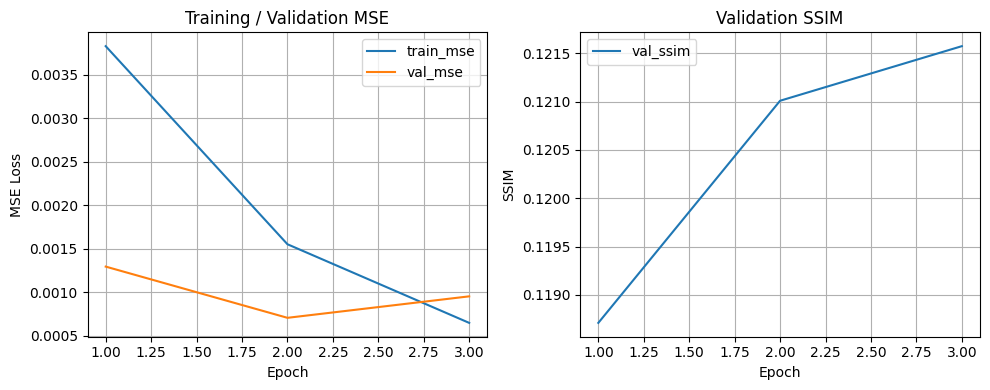

In [17]:
# Training loop (train + val), also computes SSIM on validation 
# Compute SSIM during validation and report it, using skimage SSIM robustly.
# handle small images and skimage API differences by computing a safe win_size and trying
# channel_axis first, falling back to multichannel if needed.

from torch.nn.utils import clip_grad_norm_
from skimage.metrics import structural_similarity as skimage_ssim  # using skimage SSIM 

best_val_loss = float('inf')
best_epoch = -1
no_improve_epochs = 0

train_losses = []
val_losses = []
val_ssim_scores = []   # validation SSIM per epoch

for epoch in range(1, EPOCHS+1):
    model.train()
    running_loss = 0.0
    total = 0
    pbar = tqdm.tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} Train", leave=False)
    for imgs, masks, names in pbar:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        recon = model(imgs)

        # Using MSE loss for training 
        loss = loss_function(recon, imgs)

        loss.backward()
        # gradient clipping
        if CLIP_GRAD_NORM is not None:
            clip_grad_norm_(model.parameters(), CLIP_GRAD_NORM)
        optimizer.step()

        b = imgs.size(0)
        running_loss += loss.item() * b
        total += b
        pbar.set_postfix({'loss': f"{running_loss/total:.6f}"})

    train_loss = running_loss/total
    train_losses.append(train_loss)

    # validation: compute both MSE (image-level mean MSE) and SSIM (image-level)
    model.eval()
    val_running_loss = 0.0
    val_total = 0
    val_ssim_running = 0.0
    with torch.no_grad():
        for imgs, masks, names in val_loader:
            imgs = imgs.to(device)
            recon = model(imgs)

            # MSE per image (mean over pixels and channels)
            loss = loss_function(recon, imgs)

            # SSIM per image using skimage (robust per-image call)
            imgs_np = imgs.cpu().numpy()  # [B, C, H, W]
            recon_np = recon.cpu().numpy()
            batch_ssim = []
            for i in range(imgs_np.shape[0]):
                im = np.transpose(imgs_np[i], (1,2,0)).astype(np.float32)  # H,W,C in [0,1]
                re = np.transpose(recon_np[i], (1,2,0)).astype(np.float32)
                # compute a safe win_size: must be odd and <= smaller side of the image
                h, w = im.shape[0], im.shape[1]
                min_side = min(h, w)
                # default desired win_size is 7, but must be <= min_side and odd
                desired = 7
                if min_side < desired:
                    # choose the largest odd <= min_side (and >=3 if possible)
                    win_size = min_side if (min_side % 2 == 1) else max(1, min_side - 1)
                    # ensure win_size at least 1 (skimage will complain if 1 may be too small but it's safe)
                    if win_size < 1:
                        win_size = 1
                else:
                    win_size = desired
                # ensure odd and >=1
                if win_size % 2 == 0:
                    win_size = max(1, win_size - 1)

                # Call skimage_ssim with modern or legacy args depending on availability
                try:
                    # modern signature uses channel_axis
                    s = skimage_ssim(im, re, data_range=1.0, channel_axis=2, win_size=win_size)
                except TypeError:
                    # older skimage uses multichannel param
                    s = skimage_ssim(im, re, data_range=1.0, multichannel=True, win_size=win_size)
                batch_ssim.append(s)
            val_ssim_running += float(np.mean(batch_ssim))

            b = imgs.size(0)
            val_running_loss += loss.item() * b
            val_total += b

    val_loss = val_running_loss / val_total if val_total>0 else float('nan')
    val_losses.append(val_loss)
    val_ssim = val_ssim_running / (val_total if val_total>0 else 1)
    val_ssim_scores.append(val_ssim)

    # scheduler step (ReduceLROnPlateau uses val_loss)
    scheduler.step(val_loss)

    print(f"Epoch {epoch}  train_loss={train_loss:.6f}  val_loss={val_loss:.6f}  val_ssim={val_ssim:.6f}")

    # checkpoint best val (monitoring val_loss MSE)
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        no_improve_epochs = 0
        torch.save(model.state_dict(), WORK_DIR / 'model_best_val.pth')
        print(f"  Saved best model at epoch {epoch}")
    else:
        no_improve_epochs += 1

    # early stopping
    if no_improve_epochs >= EARLY_STOPPING_PATIENCE:
        print(f"Early stopping: no improvement for {no_improve_epochs} epochs.")
        break

# Save final model
torch.save(model.state_dict(), WORK_DIR / 'model_final.pth')

print(f"Training completed. Best val epoch: {best_epoch}. Models saved to {WORK_DIR}")

# Plot training curves (MSE) and SSIM (validation)
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(range(1, len(train_losses)+1), train_losses, label='train_mse')
plt.plot(range(1, len(val_losses)+1), val_losses, label='val_mse')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss'); plt.legend(); plt.grid(True)
plt.title('Training / Validation MSE')

plt.subplot(1,2,2)
plt.plot(range(1, len(val_ssim_scores)+1), val_ssim_scores, label='val_ssim')
plt.xlabel('Epoch'); plt.ylabel('SSIM'); plt.legend(); plt.grid(True)
plt.title('Validation SSIM')

plt.tight_layout()
plt.savefig(WORK_DIR / 'loss_and_ssim_plot.png', bbox_inches='tight')
plt.show()


CELL 7 — EVALUATION ON VALIDATION

In [18]:
# Computation of per-validation-image MSE and SSIM using skimage with a robust wrapper.
# MSE used for validation scores.
# SSIM computed and saved per-image.


from skimage.metrics import structural_similarity as skimage_ssim  # safe wrapper below

# robust SSIM wrapper 
def safe_skimage_ssim(im, re, desired_win=7):
    """
    im, re : HWC numpy float arrays in [0,1]
    Returns: scalar SSIM
    This wrapper:
      - picks a safe odd win_size <= min(image_side)
      - tries modern skimage API with channel_axis; falls back to multichannel if needed
    """
    h, w = im.shape[0], im.shape[1]
    min_side = min(h, w)
    # choose win_size
    if min_side < desired_win:
        win_size = min_side if (min_side % 2 == 1) else max(1, min_side - 1)
        if win_size < 1:
            win_size = 1
    else:
        win_size = desired_win
    if win_size % 2 == 0:
        win_size = max(1, win_size - 1)
    try:
        return skimage_ssim(im, re, data_range=1.0, channel_axis=2, win_size=win_size)
    except TypeError:
        return skimage_ssim(im, re, data_range=1.0, multichannel=True, win_size=win_size)


model.eval()
val_image_scores_mse = []
val_image_ssim = []

with torch.no_grad():
    for imgs, masks, names in val_loader:
        imgs = imgs.to(device)
        recon = model(imgs)
        # MSE per-pixel then mean to get an image-level MSE
        mse_map = (imgs - recon)**2  # [B, C, H, W]
        mse_per_image = mse_map.mean(dim=[1,2,3])  # [B]
        # SSIM per image using safe_skimage_ssim
        imgs_np = imgs.cpu().numpy()
        recon_np = recon.cpu().numpy()
        for i in range(mse_per_image.shape[0]):
            val_image_scores_mse.append(float(mse_per_image[i].cpu().numpy()))
            im = np.transpose(imgs_np[i], (1,2,0)).astype(np.float32)
            re = np.transpose(recon_np[i], (1,2,0)).astype(np.float32)
            s = safe_skimage_ssim(im, re)
            val_image_ssim.append(float(s))

import pandas as pd
df_val = pd.DataFrame({'val_image_mse': val_image_scores_mse, 'val_image_ssim': val_image_ssim})
df_val.to_csv(WORK_DIR / 'val_scores_mse_ssim.csv', index=False)
print("Saved validation image MSE and SSIM to", WORK_DIR / 'val_scores_mse_ssim.csv')
print("Val MSE mean/std:", np.mean(val_image_scores_mse), np.std(val_image_scores_mse))
print("Val SSIM mean/std:", np.mean(val_image_ssim), np.std(val_image_ssim))


Saved validation image MSE and SSIM to /kaggle/working/mvtec_hazelnut_resnet_unet_mse_only/val_scores_mse_ssim.csv
Val MSE mean/std: 0.0009555646333282288 0.0029402608561320304
Val SSIM mean/std: 0.9485108011808151 0.03504428841276909


CELL 8 — FINAL TEST EVALUATION

Loading model from: /kaggle/working/mvtec_hazelnut_resnet_unet_mse_only/model_best_val.pth


Collecting: 100%|██████████| 55/55 [00:01<00:00, 27.68it/s]


Calibration set: 55 images, 901120 pixels


Collecting: 100%|██████████| 55/55 [00:01<00:00, 27.90it/s]


Final test counts -> Normal: 13, Anomalous: 42
Final Test Image AUROC (MSE mean): 0.6538, Pixel AUROC: 0.7325
Pixel thresholds chosen from calibration: {'youden_calib': 0.00035599127295427024, 'f1_calib': 0.0005651378887705505}
Saved image_threshold_experiments_finaltest.csv to /kaggle/working/mvtec_hazelnut_resnet_unet_mse_only
             thr_name  threshold  precision    recall        f1  tn  fp  fn  \
0          val_pct_95   0.003904   1.000000  0.023810  0.046512  13   0  41   
1          val_pct_97   0.011531   1.000000  0.023810  0.046512  13   0  41   
2          val_pct_99   0.013581   0.000000  0.000000  0.000000  13   0  42   
3  image_youden_calib   0.000418   0.857143  0.571429  0.685714   9   4  18   
4     range_3.045e-04   0.000305   0.759259  0.976190  0.854167   0  13   1   
5     range_2.860e-03   0.002860   1.000000  0.047619  0.090909  13   0  40   
6     range_5.415e-03   0.005415   1.000000  0.023810  0.046512  13   0  41   
7     range_7.970e-03   0.007970   1.

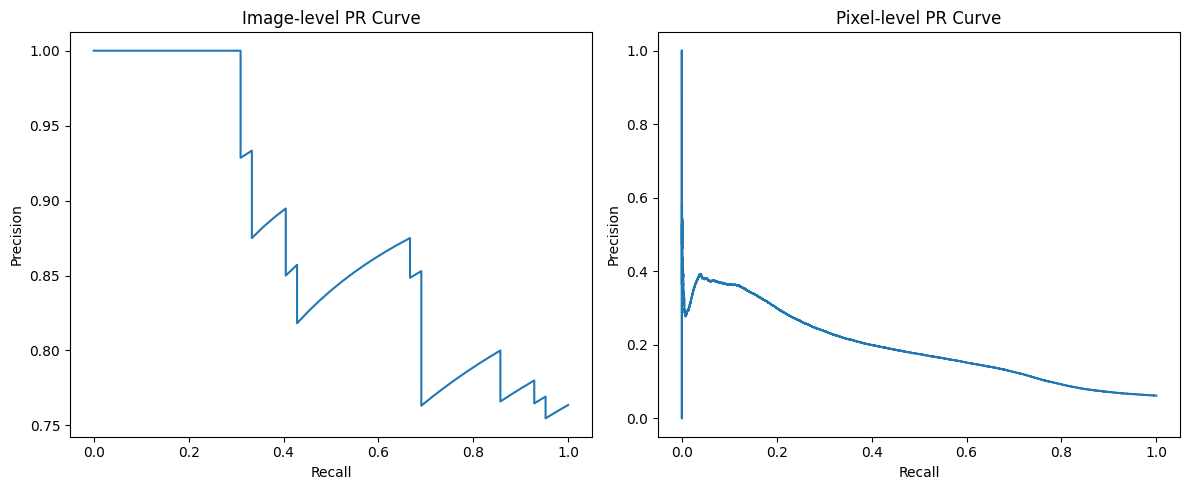

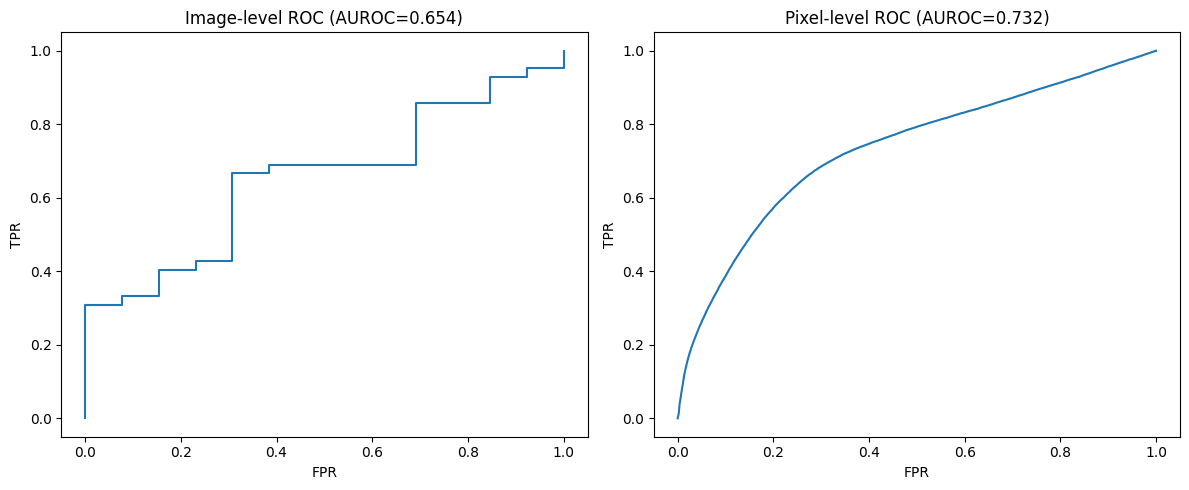

Saved final scores and metrics to /kaggle/working/mvtec_hazelnut_resnet_unet_mse_only
{
  "image_auroc_mse": 0.6538461538461539,
  "pixel_auroc": 0.732497973877925,
  "default_image_threshold": 0.0135811037383973,
  "image_threshold_experiments": [
    {
      "thr_name": "val_pct_95",
      "threshold": 0.003904442721977784,
      "precision": 1.0,
      "recall": 0.023809523809523808,
      "f1": 0.046511627906976744,
      "tn": 13,
      "fp": 0,
      "fn": 41,
      "tp": 1
    },
    {
      "thr_name": "val_pct_97",
      "threshold": 0.011530731497332417,
      "precision": 1.0,
      "recall": 0.023809523809523808,
      "f1": 0.046511627906976744,
      "tn": 13,
      "fp": 0,
      "fn": 41,
      "tp": 1
    },
    {
      "thr_name": "val_pct_99",
      "threshold": 0.0135811037383973,
      "precision": 0.0,
      "recall": 0.0,
      "f1": 0.0,
      "tn": 13,
      "fp": 0,
      "fn": 42,
      "tp": 0
    },
    {
      "thr_name": "image_youden_calib",
      "thres

In [20]:
# FINAL evaluation 
# image-level MSE scoring (consistent with training)
# SSIM using robust safe_skimage_ssim (skimage), computed for calibration and final test
# Pixel ROC computation and pixel threshold selection (Youden / F1-max) on calibration (or fallback to test)
# Experiment with multiple thresholds and report metrics across them
# Report number of normal / anomalous test images
# Report confusion matrices and class counts
# Plot & save PR curves in addition to ROC curves


from skimage.metrics import structural_similarity as skimage_ssim
from sklearn.metrics import (roc_auc_score, roc_curve, auc,
                             precision_recall_curve,
                             precision_score, recall_score, f1_score,
                             precision_recall_fscore_support,
                             confusion_matrix)
import matplotlib.pyplot as plt

# robust SSIM wrapper (same as used earlier) 
def safe_skimage_ssim(im, re, desired_win=7):
    """
    im, re : HWC numpy float arrays in [0,1]
    Returns: scalar SSIM
    This wrapper:
      - picks a safe odd win_size <= min(image_side)
      - tries modern skimage API with channel_axis; falls back to multichannel if needed
    """
    h, w = im.shape[0], im.shape[1]
    min_side = min(h, w)
    # choose win_size
    if min_side < desired_win:
        win_size = min_side if (min_side % 2 == 1) else max(1, min_side - 1)
        if win_size < 1:
            win_size = 1
    else:
        win_size = desired_win
    if win_size % 2 == 0:
        win_size = max(1, win_size - 1)
    try:
        return skimage_ssim(im, re, data_range=1.0, channel_axis=2, win_size=win_size)
    except TypeError:
        return skimage_ssim(im, re, data_range=1.0, multichannel=True, win_size=win_size)


# Ensure model is loaded (best available)
best_model_path = WORK_DIR / 'model_best_val.pth'
if not best_model_path.exists():
    best_model_path = WORK_DIR / 'model_final.pth'

print("Loading model from:", best_model_path)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

# Helper: run inference on a loader and collect image/pixel scores + SSIM + results list
def collect_scores_from_loader(loader):
    image_scores = []   # image-level mean MSE
    image_labels = []
    image_ssim_vals = []
    pixel_scores_list = []
    pixel_labels_list = []
    results_local = []
    with torch.no_grad():
        for img, mask, name in tqdm.tqdm(loader, desc="Collecting"):
            img = img.to(device)
            recon = model(img)
            per_pixel_mse_map = ((img - recon)**2).mean(dim=1, keepdim=True)  # [1,1,H,W]
            err_np = per_pixel_mse_map.squeeze().cpu().numpy()               # HxW
            mask_np = mask.squeeze().cpu().numpy()                           # HxW
            img_mean_mse = float(err_np.mean())
            img_p95 = float(np.percentile(err_np, 95))
            label = 1 if mask_np.sum() > 0 else 0
            # SSIM per-image using safe wrapper
            img_np = img.cpu().numpy()[0].transpose(1,2,0).astype(np.float32)
            recon_np = recon.cpu().numpy()[0].transpose(1,2,0).astype(np.float32)
            ssim_val = safe_skimage_ssim(img_np, recon_np)

            image_scores.append(img_mean_mse)
            image_labels.append(label)
            image_ssim_vals.append(float(ssim_val))
            pixel_scores_list.append(err_np.flatten())
            pixel_labels_list.append((mask_np>0).astype(np.uint8).flatten())
            results_local.append({
                'name': name,
                'img_mean_mse': img_mean_mse,
                'img_p95_mse': img_p95,
                'label': label,
                'err_map_mse': err_np,
                'mask': mask_np,
                'ssim': float(ssim_val)
            })
    image_scores = np.array(image_scores)
    image_labels = np.array(image_labels)
    image_ssim_vals = np.array(image_ssim_vals)
    pixel_scores = np.concatenate(pixel_scores_list) if len(pixel_scores_list) > 0 else np.array([])
    pixel_labels = np.concatenate(pixel_labels_list) if len(pixel_labels_list) > 0 else np.array([])
    return image_scores, image_labels, image_ssim_vals, pixel_scores, pixel_labels, results_local

# Collect calibration scores (used to choose thresholds) if calibration set exists
if len(calib_dataset) > 0:
    print("Collecting calibration scores (for threshold selection) on calibration subset...")
    calib_image_scores, calib_image_labels, calib_image_ssim, calib_pixel_scores, calib_pixel_labels, calib_results = collect_scores_from_loader(calib_loader)
    print(f"Calibration set: {len(calib_image_scores)} images, {len(calib_pixel_labels)} pixels")
else:
    calib_image_scores = np.array([])
    calib_image_labels = np.array([])
    calib_image_ssim = np.array([])
    calib_pixel_scores = np.array([])
    calib_pixel_labels = np.array([])
    calib_results = []

# Collect final test set scores (for final evaluation)
print("Collecting final test scores...")
test_image_scores, test_image_labels, test_image_ssim, test_pixel_scores, test_pixel_labels, test_results = collect_scores_from_loader(final_test_loader)

# report counts of normal / anomalous test images
num_normal = int((test_image_labels == 0).sum())
num_anom = int((test_image_labels == 1).sum())
print(f"Final test counts -> Normal: {num_normal}, Anomalous: {num_anom}")

# Compute AUROCs (image & pixel) if possible
image_auroc = roc_auc_score(test_image_labels, test_image_scores) if len(set(test_image_labels))>1 else float('nan')
pixel_auroc = roc_auc_score(test_pixel_labels, test_pixel_scores) if len(set(test_pixel_labels))>1 else float('nan')
print(f"Final Test Image AUROC (MSE mean): {image_auroc:.4f}, Pixel AUROC: {pixel_auroc:.4f}")


# Pixel ROC & selection of pixel thresholds (Youden and F1-max)
# Prefer to use calibration pixels if available; otherwise use test pixels (less ideal).
pixel_thresholds_chosen = {}
if len(calib_pixel_labels) > 0 and len(set(calib_pixel_labels)) > 1:
    # Pixel ROC on calibration
    fpr_p, tpr_p, thr_p = roc_curve(calib_pixel_labels, calib_pixel_scores)
    youden_idx = np.argmax(tpr_p - fpr_p)
    pixel_thresholds_chosen['youden_calib'] = float(thr_p[youden_idx])
    # Pixel PR/F1-max on calibration
    prec_p, rec_p, thr_pr_p = precision_recall_curve(calib_pixel_labels, calib_pixel_scores)
    f1s = (2*prec_p*rec_p) / (prec_p + rec_p + 1e-12)
    best_idx = np.nanargmax(f1s)
    # thr_pr_p length is one less than prec/rec arrays; handle mapping
    if best_idx < len(thr_pr_p):
        pixel_thresholds_chosen['f1_calib'] = float(thr_pr_p[best_idx])
    else:
        pixel_thresholds_chosen['f1_calib'] = float(thr_pr_p[-1])
    print("Pixel thresholds chosen from calibration:", pixel_thresholds_chosen)
elif len(test_pixel_labels) > 0 and len(set(test_pixel_labels)) > 1:
    # Fallback to using test pixels (not ideal, but possible)
    fpr_p, tpr_p, thr_p = roc_curve(test_pixel_labels, test_pixel_scores)
    youden_idx = np.argmax(tpr_p - fpr_p)
    pixel_thresholds_chosen['youden_test_fallback'] = float(thr_p[youden_idx])
    prec_p, rec_p, thr_pr_p = precision_recall_curve(test_pixel_labels, test_pixel_scores)
    f1s = (2*prec_p*rec_p) / (prec_p + rec_p + 1e-12)
    best_idx = np.nanargmax(f1s)
    if best_idx < len(thr_pr_p):
        pixel_thresholds_chosen['f1_test_fallback'] = float(thr_pr_p[best_idx])
    else:
        pixel_thresholds_chosen['f1_test_fallback'] = float(thr_pr_p[-1])
    print("Pixel thresholds chosen from test (fallback):", pixel_thresholds_chosen)
else:
    print("Not enough pixel labels to compute pixel ROC/PR thresholds.")

-
# Experiment with several image-level thresholds and report performance across them
# Candidate thresholds:
# percentiles of validation MSE (val is normal-only) if available
# candidates from calibration (if anomalous examples present)
# evenly spaced thresholds across test image score range
val_thr_candidates = []
try:
    val_df = pd.read_csv(WORK_DIR / 'val_scores_mse_ssim.csv')
    val_mse_scores = val_df['val_image_mse'].values
    for p in [95, 97, 99]:
        val_thr_candidates.append(('val_pct_' + str(p), float(np.percentile(val_mse_scores, p))))
except Exception:
    val_mse_scores = np.array([])

image_thr_candidates = []
# add val percentiles
for name, t in val_thr_candidates:
    image_thr_candidates.append((name, t))

# add calibration-based image Youden if available
if len(calib_image_labels) > 1 and len(set(calib_image_labels)) > 1:
    fpr_i, tpr_i, thr_i = roc_curve(calib_image_labels, calib_image_scores)
    youden_idx_i = np.argmax(tpr_i - fpr_i)
    image_thr_candidates.append(('image_youden_calib', float(thr_i[youden_idx_i])))

# add some evenly spaced thresholds across test scores
if test_image_scores.size > 0:
    min_s, max_s = float(test_image_scores.min()), float(test_image_scores.max())
    for t in np.linspace(min_s, max_s, num=6):
        image_thr_candidates.append((f'range_{t:.3e}', float(t)))

# Remove duplicates while preserving order
seen = set()
image_thr_candidates_unique = []
for name, t in image_thr_candidates:
    if t not in seen:
        image_thr_candidates_unique.append((name, t))
        seen.add(t)

# Evaluate metrics across these image thresholds
threshold_rows = []
for thr_name, thr in image_thr_candidates_unique:
    preds = (test_image_scores > thr).astype(int)
    prec, rec, f1, _ = precision_recall_fscore_support(test_image_labels, preds, average='binary', zero_division=0)
    cm = confusion_matrix(test_image_labels, preds)
    tn = int(cm[0,0]) if cm.shape == (2,2) else int(cm[0,0])
    fp = int(cm[0,1]) if cm.shape == (2,2) else 0
    fn = int(cm[1,0]) if cm.shape == (2,2) else 0
    tp = int(cm[1,1]) if cm.shape == (2,2) else 0
    threshold_rows.append({
        'thr_name': thr_name,
        'threshold': thr,
        'precision': float(prec),
        'recall': float(rec),
        'f1': float(f1),
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp
    })

thr_df = pd.DataFrame(threshold_rows)
thr_df.to_csv(WORK_DIR / 'image_threshold_experiments_finaltest.csv', index=False)
print("Saved image_threshold_experiments_finaltest.csv to", WORK_DIR)
print(thr_df)

# Choose a default image threshold (prefer val 99th percentile if available, else first candidate)
if len(val_mse_scores) > 0:
    default_image_thr = float(np.percentile(val_mse_scores, 99))
else:
    default_image_thr = image_thr_candidates_unique[0][1] if len(image_thr_candidates_unique) > 0 else None

# Evaluate default image threshold and print confusion matrix
if default_image_thr is not None:
    default_preds = (test_image_scores > default_image_thr).astype(int)
    d_prec, d_rec, d_f1, _ = precision_recall_fscore_support(test_image_labels, default_preds, average='binary', zero_division=0)
    cm_default = confusion_matrix(test_image_labels, default_preds)
    print(f"Default image threshold (val 99pct if available) = {default_image_thr:.6e}")
    print(f"Image-level @ default threshold: Precision={d_prec:.4f}, Recall={d_rec:.4f}, F1={d_f1:.4f}")
    print("Confusion matrix (rows true 0/1, cols pred 0/1):")
    print(cm_default)
else:
    print("No image threshold available to compute default metrics.")

# If pixel thresholds were chosen above, evaluate pixel-level metrics
pixel_metrics_report = {}
for name, pthr in pixel_thresholds_chosen.items():
    if test_pixel_scores.size > 0:
        p_preds = (test_pixel_scores > pthr).astype(int)
        p_prec, p_rec, p_f1, _ = precision_recall_fscore_support(test_pixel_labels, p_preds, average='binary', zero_division=0)
        cm_p = confusion_matrix(test_pixel_labels, p_preds)
        pixel_metrics_report[name] = {'threshold': pthr, 'precision': float(p_prec), 'recall': float(p_rec), 'f1': float(p_f1), 'cm': cm_p.tolist()}
    else:
        pixel_metrics_report[name] = {'threshold': pthr, 'note': 'no test pixel scores'}

# Save pixel threshold results
with open(WORK_DIR / 'pixel_thresholds_report.json','w') as f:
    json.dump(pixel_metrics_report, f, indent=2)
print("Saved pixel threshold report to", WORK_DIR / 'pixel_thresholds_report.json')
print("Pixel thresholds report:", pixel_metrics_report)


# PR curves and ROC curves (image and pixel). Save plots.

# Image-level PR curve
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
if len(set(test_image_labels)) > 1:
    img_prec, img_rec, _ = precision_recall_curve(test_image_labels, test_image_scores)
    plt.plot(img_rec, img_prec)
    plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Image-level PR Curve')
else:
    plt.text(0.5, 0.5, 'Not enough classes for Image PR', ha='center')

# Pixel-level PR curve
plt.subplot(1,2,2)
if len(set(test_pixel_labels)) > 1:
    p_prec, p_rec, _ = precision_recall_curve(test_pixel_labels, test_pixel_scores)
    plt.plot(p_rec, p_prec)
    plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('Pixel-level PR Curve')
else:
    plt.text(0.5, 0.5, 'Not enough classes for Pixel PR', ha='center')

plt.tight_layout()
plt.savefig(WORK_DIR / 'pr_curves_finaltest.png', bbox_inches='tight')
plt.show()

# ROC curves
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
if len(set(test_image_labels)) > 1:
    fpr_i, tpr_i, _ = roc_curve(test_image_labels, test_image_scores)
    roc_auc_i = auc(fpr_i, tpr_i)
    plt.plot(fpr_i, tpr_i)
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'Image-level ROC (AUROC={roc_auc_i:.3f})')
else:
    plt.text(0.5, 0.5, 'Not enough classes for Image ROC', ha='center')

plt.subplot(1,2,2)
if len(set(test_pixel_labels)) > 1:
    fpr_p, tpr_p, _ = roc_curve(test_pixel_labels, test_pixel_scores)
    roc_auc_p = auc(fpr_p, tpr_p)
    plt.plot(fpr_p, tpr_p)
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title(f'Pixel-level ROC (AUROC={roc_auc_p:.3f})')
else:
    plt.text(0.5, 0.5, 'Not enough classes for Pixel ROC', ha='center')

plt.tight_layout()
plt.savefig(WORK_DIR / 'roc_curves_finaltest.png', bbox_inches='tight')
plt.show()


# Save per-image CSV and summary metrics to disk
rows = []
for r in test_results:
    rows.append({'name': r['name'], 'img_mean_mse': r['img_mean_mse'], 'img_p95_mse': r['img_p95_mse'], 'label': r['label'], 'ssim': r['ssim']})
df_final = pd.DataFrame(rows)
if default_image_thr is not None:
    df_final['pred_label_default'] = (df_final['img_mean_mse'] > default_image_thr).astype(int)
df_final.to_csv(WORK_DIR / 'scores_mse_ssim_finaltest.csv', index=False)

summary_metrics = {
    'image_auroc_mse': float(image_auroc) if not np.isnan(image_auroc) else None,
    'pixel_auroc': float(pixel_auroc) if not np.isnan(pixel_auroc) else None,
    'default_image_threshold': float(default_image_thr) if default_image_thr is not None else None,
    'image_threshold_experiments': thr_df.to_dict(orient='records'),
    'pixel_thresholds_chosen': pixel_thresholds_chosen,
    'pixel_thresholds_report': pixel_metrics_report,
    'test_num_normal': num_normal,
    'test_num_anomalous': num_anom,
}
with open(WORK_DIR / 'metrics_mse_ssim_final.json','w') as f:
    json.dump(summary_metrics, f, indent=2)

print("Saved final scores and metrics to", WORK_DIR)
print(json.dumps(summary_metrics, indent=2))



CELL 9 — VISUALIZE EXAMPLES

Displaying 6 example visualizations:


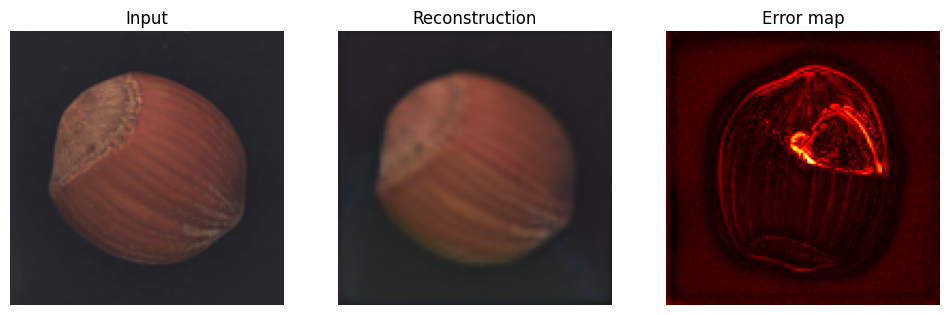

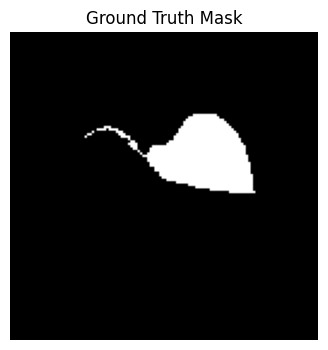

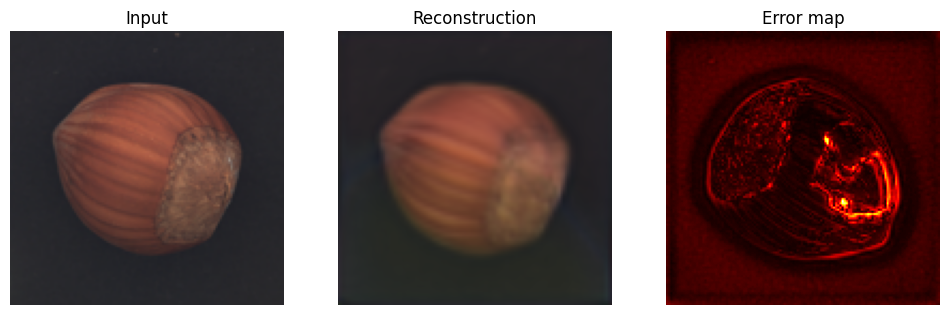

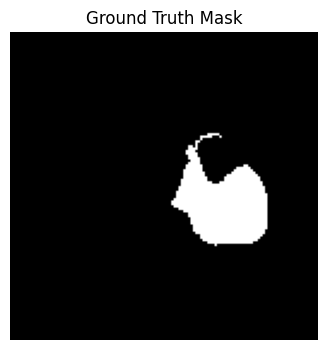

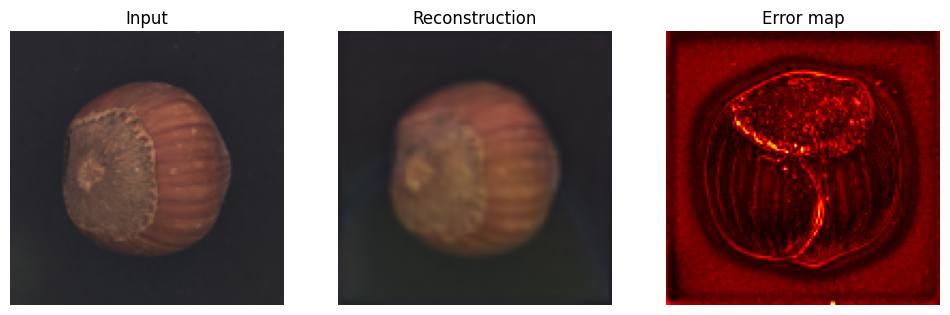

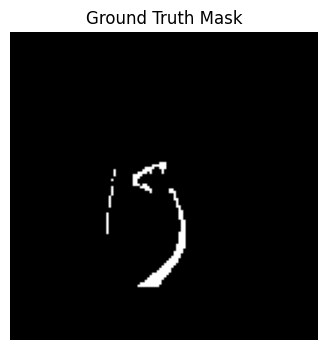

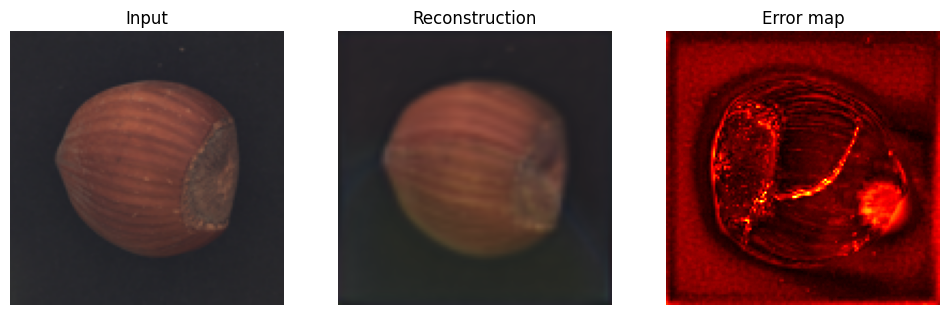

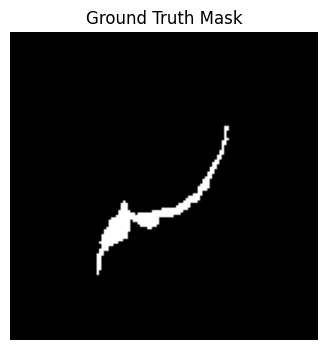

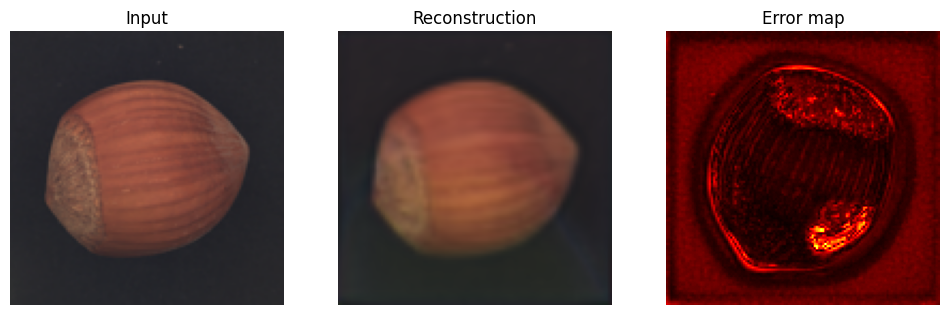

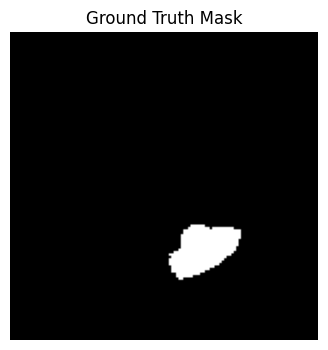

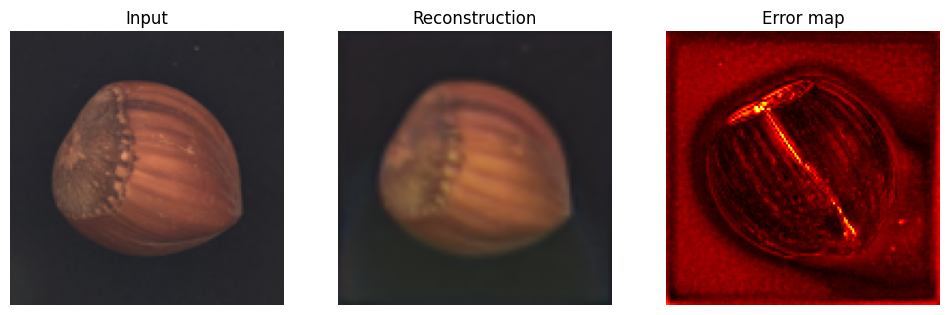

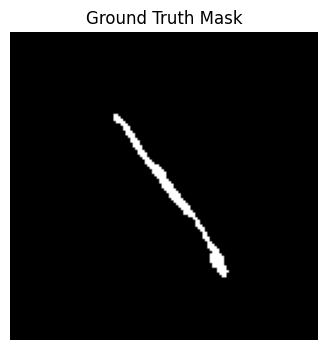

In [21]:
# Show N example visualizations of Input / Reconstruction / Error map
def show_example_plots(idx, results):
    r = results[idx]
    err = r['err_map']
    
    # If 'mask' is not available 
    mask = r.get('mask', None)
    
    # Try to find the input image on disk
    img_path = None
    for sub in (category_root / 'test').iterdir():
        p = sub / r['name'][0]
        if p.exists():
            img_path = p
            break

    if img_path:
        img = Image.open(img_path).convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
        inp = np.array(img).astype(np.float32) / 255.0
    else:
        inp = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 3))
    
    # Produce reconstruction
    img_t = test_transform(Image.fromarray((inp * 255).astype(np.uint8))).unsqueeze(0).to(device)
    with torch.no_grad():
        recon = model(img_t).cpu().squeeze().permute(1, 2, 0).numpy()
        
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 3, 1); plt.imshow(inp); plt.title('Input'); plt.axis('off')
    plt.subplot(1, 3, 2); plt.imshow(np.clip(recon, 0, 1)); plt.title('Reconstruction'); plt.axis('off')
    plt.subplot(1, 3, 3); plt.imshow(err, cmap='hot'); plt.title('Error map'); plt.axis('off')
    
    # Only show mask if it exists
    if mask is not None:
        plt.figure(figsize=(4, 4))
        plt.imshow(mask.squeeze(), cmap='gray')
        plt.title('Ground Truth Mask')
        plt.axis('off')
    
    plt.show()

# Display N examples
N = min(6, len(results))
print(f"Displaying {N} example visualizations:")
for i in range(N):
    show_example_plots(i, results)
